In [17]:
import pandas as pd

df = pd.read_excel('./linelist_raw.xlsx')
df.head()

,case_id,generation,infection date,date onset,hosp date,date_of_outcome,outcome,gender,hospital,lon,...,ct_blood,fever,chills,cough,aches,vomit,temp,time_admission,merged_header,Unnamed: 27
0,5fe599,4.0,2014-05-08,2014-05-13,2014-05-15,NaT,NaN,m,Other,-13.215735,...,22.0,no,no,yes,no,yes,36.8,NaN,a,b
1,8689b7,4.0,NaT,2014-05-13,2014-05-14,2014-05-18,Recover,f,NaN,-13.215234,...,22.0,NaN,NaN,NaN,NaN,NaN,36.9,09:36,a,b
2,11f8ea,2.0,NaT,2014-05-16,2014-05-18,2014-05-30,Recover,m,St. Mark's Maternity Hospital (SMMH),-13.212911,...,21.0,NaN,NaN,NaN,NaN,NaN,36.9,16:48,a,b
3,b8812a,3.0,2014-05-04,2014-05-18,2014-05-20,NaT,NaN,f,Port Hospital,-13.236371,...,23.0,no,no,no,no,no,36.8,11:22,a,b
4,893f25,3.0,2014-05-18,2014-05-21,2014-05-22,2014-05-29,Recover,m,Military Hospital,-13.222864,...,23.0,no,no,yes,no,yes,36.9,12:60,a,b


In [18]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 6611 entries, 0 to 6610
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   case_id          6604 non-null   str           
 1   generation       6604 non-null   float64       
 2   infection date   4289 non-null   datetime64[us]
 3   date onset       6318 non-null   str           
 4   hosp date        6604 non-null   datetime64[us]
 5   date_of_outcome  5543 non-null   datetime64[us]
 6   outcome          5111 non-null   str           
 7   gender           6287 non-null   str           
 8   hospital         5099 non-null   str           
 9   lon              6604 non-null   float64       
 10  lat              6604 non-null   float64       
 11  infector         4288 non-null   str           
 12  source           4288 non-null   str           
 13  age              6504 non-null   float64       
 14  age_unit         6604 non-null   str           
 15

In [19]:
df.describe()

,generation,infection date,hosp date,date_of_outcome,lon,lat,age,row_num,wt_kg,ht_cm,ct_blood,temp
count,6604.000000,4289,6604,5543,6604.000000,6604.000000,6504.000000,6611.000000,6604.000000,6604.000000,6604.000000,6453.000000
mean,16.598274,2014-08-17 15:30:00.419678,2014-08-31 05:10:56.329497,2014-09-11 00:04:09.395634,-13.233829,8.469685,16.103629,3240.914688,52.693216,125.245003,21.262114,38.597102
min,0.000000,2012-04-09 00:00:00,2012-04-20 00:00:00,2012-05-14 00:00:00,-13.272755,8.446206,0.000000,1.000000,-11.000000,4.000000,16.000000,35.200000
25%,13.000000,2014-08-25 00:00:00,2014-09-07 00:00:00,2014-09-14 00:00:00,-13.251579,8.461235,6.000000,1647.500000,41.000000,91.000000,20.000000,38.300000
50%,16.000000,2014-10-04 00:00:00,2014-10-15 00:00:00,2014-10-26 00:00:00,-13.229079,8.469072,13.000000,3241.000000,54.000000,130.000000,22.000000,38.800000
75%,20.000000,2014-11-26 00:00:00,2014-12-10 00:00:00,2014-12-21 00:00:00,-13.216586,8.479571,23.000000,4836.500000,66.000000,159.000000,22.000000,39.200000
max,37.000000,2015-04-27 00:00:00,2015-04-30 00:00:00,2015-06-04 00:00:00,-13.205224,8.491748,84.000000,6481.000000,111.000000,295.000000,26.000000,40.800000
std,5.714777,NaN,NaN,NaN,0.019447,0.011276,12.621254,1857.829718,18.589333,49.568585,1.665195,0.954342


## fixing data column datatypes for memory efficiency

a. ensure columsn are correct types
b. inspect duplicates
c.	Inspect missingness (except for the columns “fever”, “chills”, “cough”, “aches” ,“vomit”) and comment on which columns have missing values and how you would handle it
d.	Clean string type columns (like outcome, gender, hospital etc.) where necessary 
e.	Look at ranges for numbers; do they make sense? If not handle them accordingly.

In [20]:
# a
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['generation'] = pd.to_numeric(df['generation'], errors='coerce')

In [21]:
# b
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

Number of duplicate rows: 2


In [22]:
# c
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
case_id               7
generation            7
infection date     2322
date onset          293
hosp date             7
date_of_outcome    1068
outcome            1500
gender              324
hospital           1512
lon                   7
lat                   7
infector           2323
source             2323
age                 107
age_unit              7
row_num               0
wt_kg                 7
ht_cm                 7
ct_blood              7
fever               258
chills              258
cough               258
aches               258
vomit               258
temp                158
time_admission      844
merged_header         0
Unnamed: 27           0
dtype: int64


In [29]:
# d
print(df['outcome'].unique())
print('thats fine, moving on\n\n')

print(df['gender'].unique())
print('thats fine, moving on\n\n')

# fix spelling mistakes and semantic couplings
df['hospital'] = df['hospital'].str.replace('Hopital', 'Hospital', regex=False)
df['hospital'] = df['hospital'].str.replace("St. Mark's", 'St. Marks', regex=False)
df['hospital'] = df['hospital'].str.replace('Mitylira', 'Military', regex=False)
print(df['hospital'].unique())

<StringArray>
[nan, 'Recover', 'Death']
Length: 3, dtype: str
thats fine, moving on


<StringArray>
['m', 'f', nan]
Length: 3, dtype: str
thats fine, moving on


<StringArray>
[                              'Other',                                   nan,
 'St. Marks Maternity Hospital (SMMH)',                       'Port Hospital',
                   'Military Hospital',                    'Central Hospital',
                          'Hospital A',                          'Hospital B']
Length: 8, dtype: str


In [44]:
# e
pd.set_option('display.max_columns', None)  # Show all columns

print(df['age'].describe())
print(f'There are {df[df["age"] == 0].shape[0]} rows with age 0, needs inspection\n\n')

print(df['wt_kg'].describe())
print("there's a negative weight??\n\n")

print(df['ht_cm'].describe())
print("Really? 4 cm tall??\n\n")

print(df['temp'].describe())
print("Temp looks good")

count    6504.000000
mean       16.103629
std        12.621254
min         0.000000
25%         6.000000
50%        13.000000
75%        23.000000
max        84.000000
Name: age, dtype: float64
There are 136 rows with age 0, needs inspection


count    6604.000000
mean       52.693216
std        18.589333
min       -11.000000
25%        41.000000
50%        54.000000
75%        66.000000
max       111.000000
Name: wt_kg, dtype: float64
there's a negative weight??


count    6604.000000
mean      125.245003
std        49.568585
min         4.000000
25%        91.000000
50%       130.000000
75%       159.000000
max       295.000000
Name: ht_cm, dtype: float64
Really? 4 cm tall??


count    6453.000000
mean       38.597102
std         0.954342
min        35.200000
25%        38.300000
50%        38.800000
75%        39.200000
max        40.800000
Name: temp, dtype: float64
Temp looks good


## plot the data

a. plot hospitalization cases over time by gender

b. how long people take to get hospitalized after showing first symptoms

c. plot number of cases per hospital

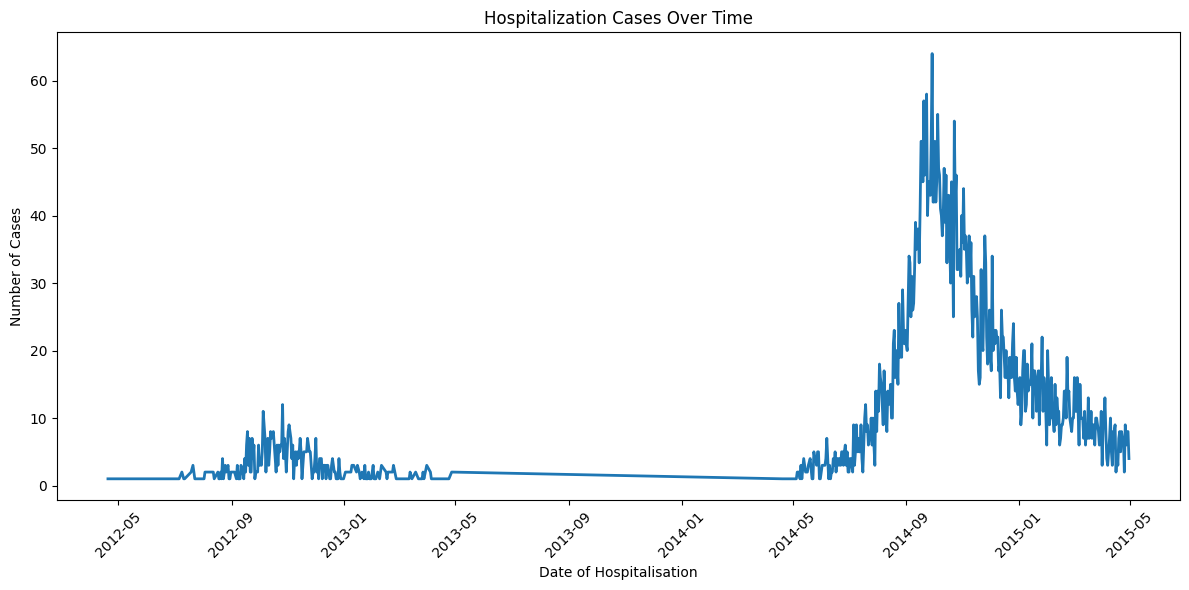

In [52]:
# plot hospitalization cases over time using matplotlib
import matplotlib.pyplot as plt

hosp_cases = df[['hosp date']].copy()
hosp_cases['hosp date'] = pd.to_datetime(hosp_cases['hosp date'], errors='coerce')
hosp_cases = hosp_cases.dropna(subset=['hosp date'])

cases_over_time = (
    hosp_cases.groupby('hosp date')
    .size()
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(cases_over_time.index, cases_over_time.values, linewidth=2)
plt.xlabel('Date of Hospitalisation')
plt.ylabel('Number of Cases')
plt.title('Hospitalization Cases Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

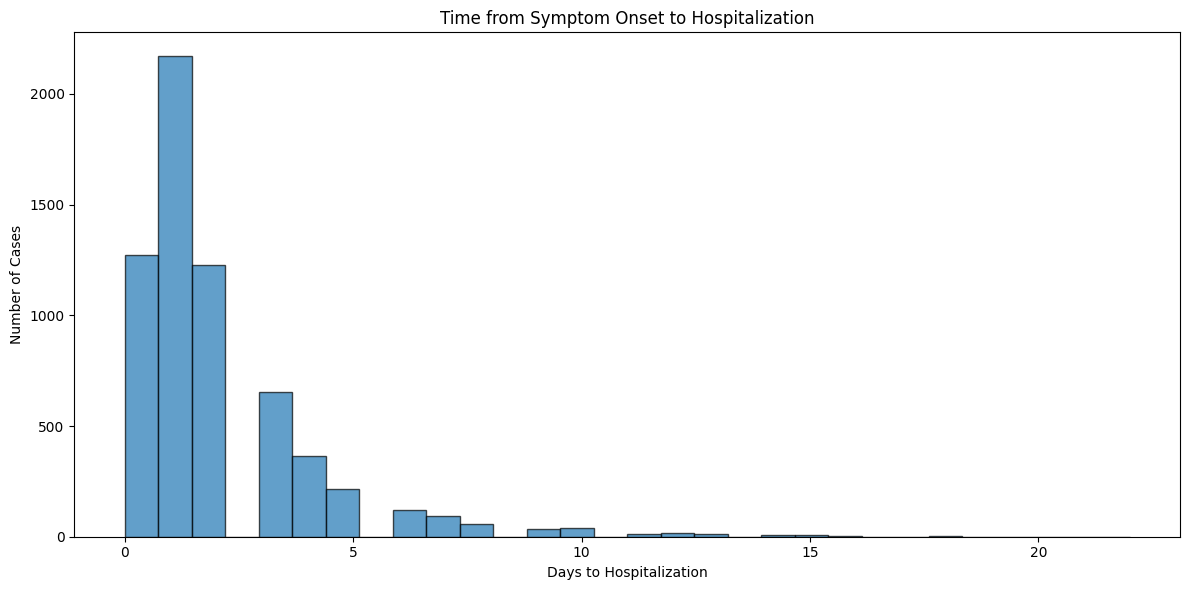

In [54]:
# b. how long people take to get hospitalized after showing first symptoms
import matplotlib.pyplot as plt

# Calculate the difference between hospitalization date and symptom onset date
df['hosp date'] = pd.to_datetime(df['hosp date'], errors='coerce')
df['date onset'] = pd.to_datetime(df['date onset'], errors='coerce')
df['days_to_hospitalization'] = (df['hosp date'] - df['date onset']).dt.days

# Drop rows with missing values
df_days = df.dropna(subset=['days_to_hospitalization'])

# Plot the distribution
plt.figure(figsize=(12, 6))
plt.hist(df_days['days_to_hospitalization'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Days to Hospitalization')
plt.ylabel('Number of Cases')
plt.title('Time from Symptom Onset to Hospitalization')
plt.tight_layout()
plt.show()

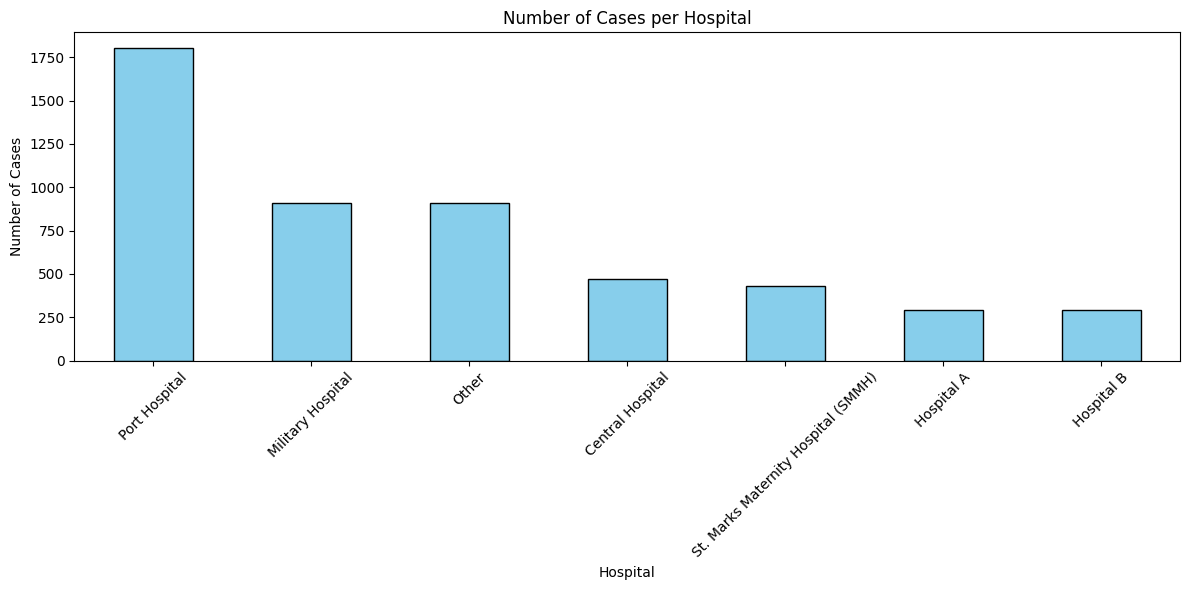

In [55]:
# c. plot number of cases per hospital

hospital_cases = df['hospital'].value_counts()
plt.figure(figsize=(12, 6))
hospital_cases.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Hospital')
plt.ylabel('Number of Cases')
plt.title('Number of Cases per Hospital')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## ⁠Impute missing symptoms columns by:

a.	Plotting the number of times each symptom was observed for each temperature (Tip: it might be worth it to organize your temperature into bins)

b.	Writing a function to set the symptom to “yes” or “no” depending on the temperature recorded

c.	Apply the function to your dataframe


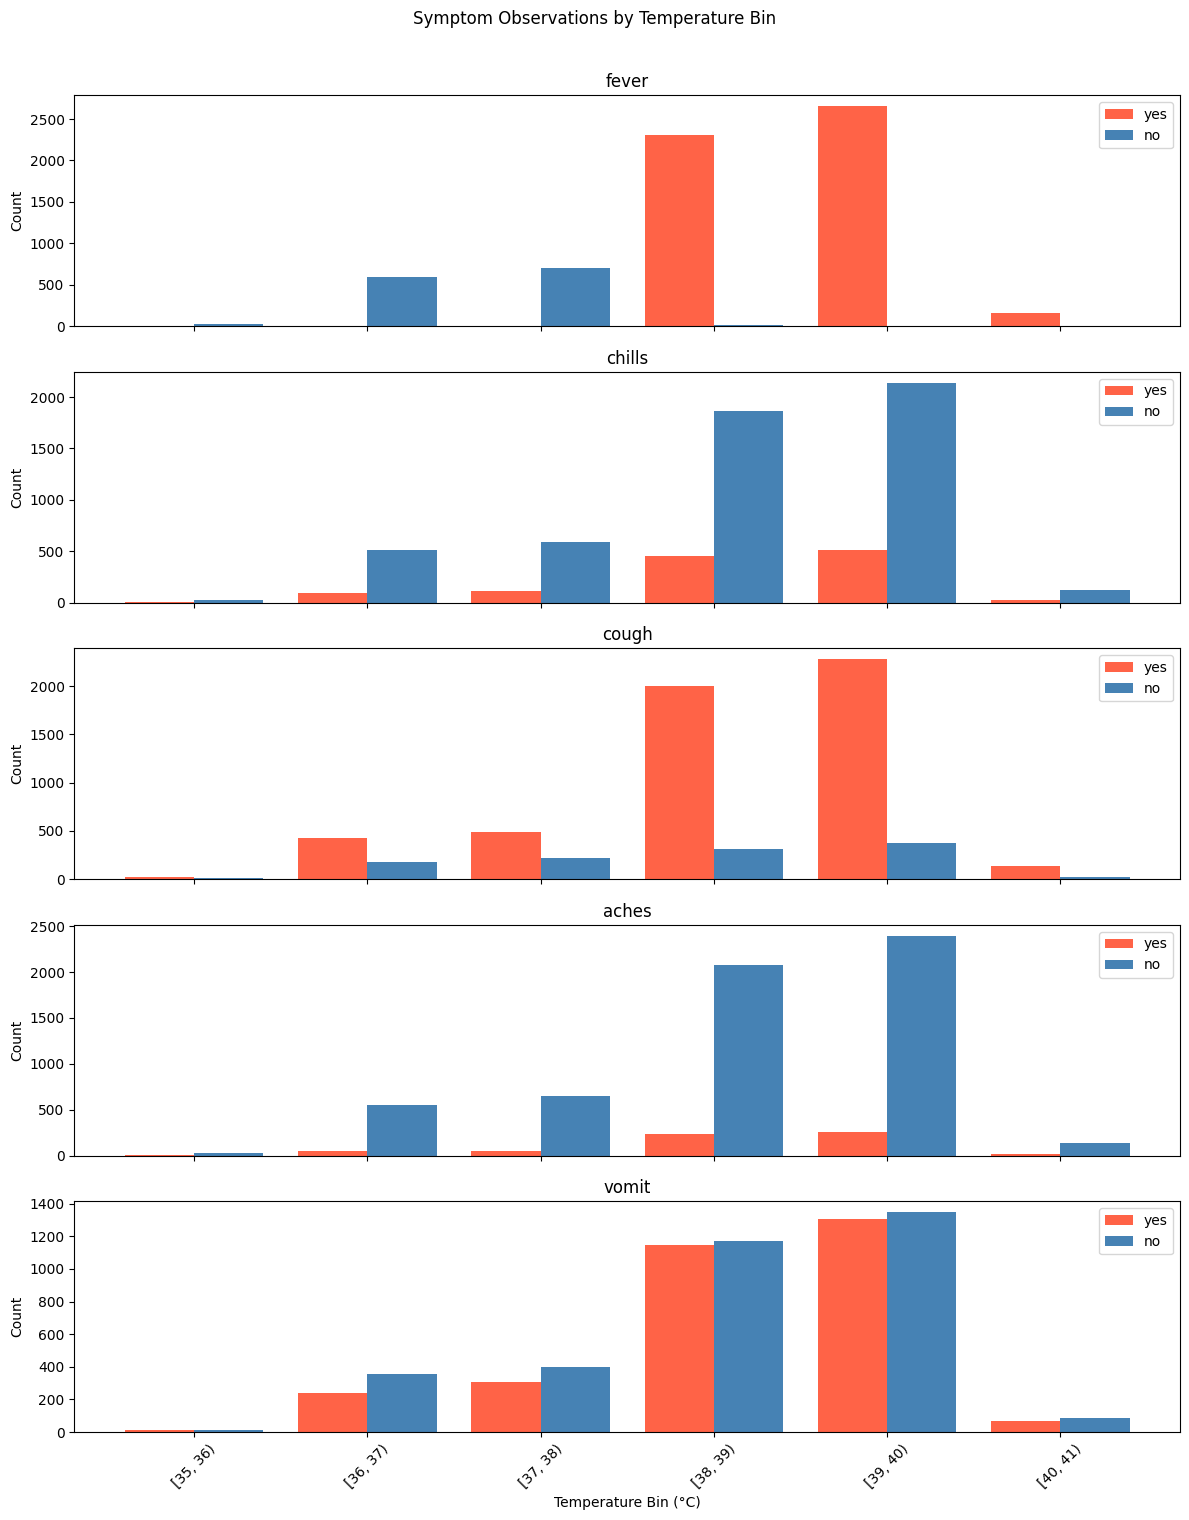

In [59]:
# a. plot symptom counts per temperature bin
import matplotlib.pyplot as plt

symptoms = ['fever', 'chills', 'cough', 'aches', 'vomit']

# Bin temperature into 1-degree intervals
df['temp_bin'] = pd.cut(df['temp'], bins=range(35, 42), right=False)
all_bins = df['temp_bin'].cat.categories

fig, axes = plt.subplots(len(symptoms), 1, figsize=(12, 3 * len(symptoms)), sharex=True)

for ax, symptom in zip(axes, symptoms):
    symptom_yes = df[df[symptom] == 'yes'].groupby('temp_bin', observed=False).size().reindex(all_bins, fill_value=0)
    symptom_no  = df[df[symptom] == 'no'].groupby('temp_bin', observed=False).size().reindex(all_bins, fill_value=0)
    x = range(len(all_bins))
    ax.bar([i - 0.2 for i in x], symptom_yes.values, width=0.4, label='yes', color='tomato')
    ax.bar([i + 0.2 for i in x], symptom_no.values,  width=0.4, label='no',  color='steelblue')
    ax.set_title(f'{symptom}')
    ax.set_ylabel('Count')
    ax.legend()
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(b) for b in all_bins], rotation=45)

axes[-1].set_xlabel('Temperature Bin (°C)')
plt.suptitle('Symptom Observations by Temperature Bin', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# b. function to impute symptom based on temperature
# From the plot: symptoms more prevalent at higher temps — use 38.0°C as threshold
def impute_symptom(row, symptom_col, threshold=38.0):
    if pd.notna(row[symptom_col]):
        return row[symptom_col]  # already has a value, keep it
    if pd.isna(row['temp']):
        return 'no'              # no temp data, default to no
    return 'yes' if row['temp'] >= threshold else 'no'

In [58]:
# c. apply the imputation function to the dataframe
symptoms = ['fever', 'chills', 'cough', 'aches', 'vomit']

for symptom in symptoms:
    df[symptom] = df.apply(lambda row: impute_symptom(row, symptom), axis=1)

print("Missing values after imputation:")
print(df[symptoms].isnull().sum())

Missing values after imputation:
fever     0
chills    0
cough     0
aches     0
vomit     0
dtype: int64


In [60]:
# Impute missing dates using median intervals between adjacent date columns
import pandas as pd

date_cols = ['infection date', 'date onset', 'hosp date', 'date_of_outcome']

# Ensure all date columns are datetime
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Pre-compute median gaps between each adjacent pair of date columns
median_gaps = {}
for i in range(len(date_cols) - 1):
    earlier, later = date_cols[i], date_cols[i + 1]
    diff = (df[later] - df[earlier]).dropna()
    median_gaps[(earlier, later)] = diff.median()
    print(f"Median {earlier} → {later}: {median_gaps[(earlier, later)].days} days")

print()

# Impute each missing date from its neighbours
for i, col in enumerate(date_cols):
    missing_mask = df[col].isna()
    if not missing_mask.any():
        continue

    has_prev = i > 0
    has_next = i < len(date_cols) - 1

    for idx in df[missing_mask].index:
        prev_date = df.loc[idx, date_cols[i - 1]] if has_prev else pd.NaT
        next_date = df.loc[idx, date_cols[i + 1]] if has_next else pd.NaT

        if pd.notna(prev_date) and pd.notna(next_date):
            # Interpolate midpoint between surrounding known dates
            df.loc[idx, col] = prev_date + (next_date - prev_date) / 2
        elif pd.notna(prev_date):
            df.loc[idx, col] = prev_date + median_gaps[(date_cols[i - 1], col)]
        elif pd.notna(next_date):
            df.loc[idx, col] = next_date - median_gaps[(col, date_cols[i + 1])]
        # If no adjacent dates available, leave as NaT

print("Missing dates after imputation:")
print(df[date_cols].isna().sum())

Median infection date → date onset: 8 days
Median date onset → hosp date: 1 days
Median hosp date → date_of_outcome: 7 days

Missing dates after imputation:
infection date     100
date onset           7
hosp date            7
date_of_outcome      7
dtype: int64


# PART 2

In [69]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

gdf = gpd.read_file('zaf_admin_boundaries.shp/zaf_admin1.shp')

# Normalize: lowercase, remove all spaces and hyphens
def normalize(s):
    return s.str.lower().str.replace(' ', '', regex=False).str.replace('-', '', regex=False)

gdf['join_key'] = normalize(gdf['adm1_name'])

# Manual fixes for known mismatches in the shapefile
gdf['join_key'] = gdf['join_key'].replace({
    'notherncape': 'northerncape',   # typo in shapefile
    'limpopo': 'northernprovince',   # CSV uses old name "Northern Province"
})

vacc = pd.read_csv('immunization_subnational_zaf.csv')
bcg = (
    vacc[
        (vacc['Indicator'] == 'BCG vaccination received') &
        (vacc['SurveyYear'] == 1998)  # single year to avoid duplicate rows
    ][['CharacteristicLabel', 'Value']]
    .copy()
)
bcg['join_key'] = normalize(bcg['CharacteristicLabel'])

gdf = gdf.merge(bcg[['join_key', 'Value']], on='join_key', how='left')

print(gdf[['adm1_name', 'join_key', 'Value']])

       adm1_name          join_key  Value
0   Eastern Cape       easterncape   95.6
1     Free State         freestate   95.1
2        Gauteng           gauteng   97.6
3  KwaZulu-Natal      kwazulunatal   97.0
4        Limpopo  northernprovince   96.9
5     Mpumalanga        mpumalanga   96.4
6     North West         northwest   95.7
7   Nothern Cape      northerncape   97.5
8   Western Cape       westerncape   98.3


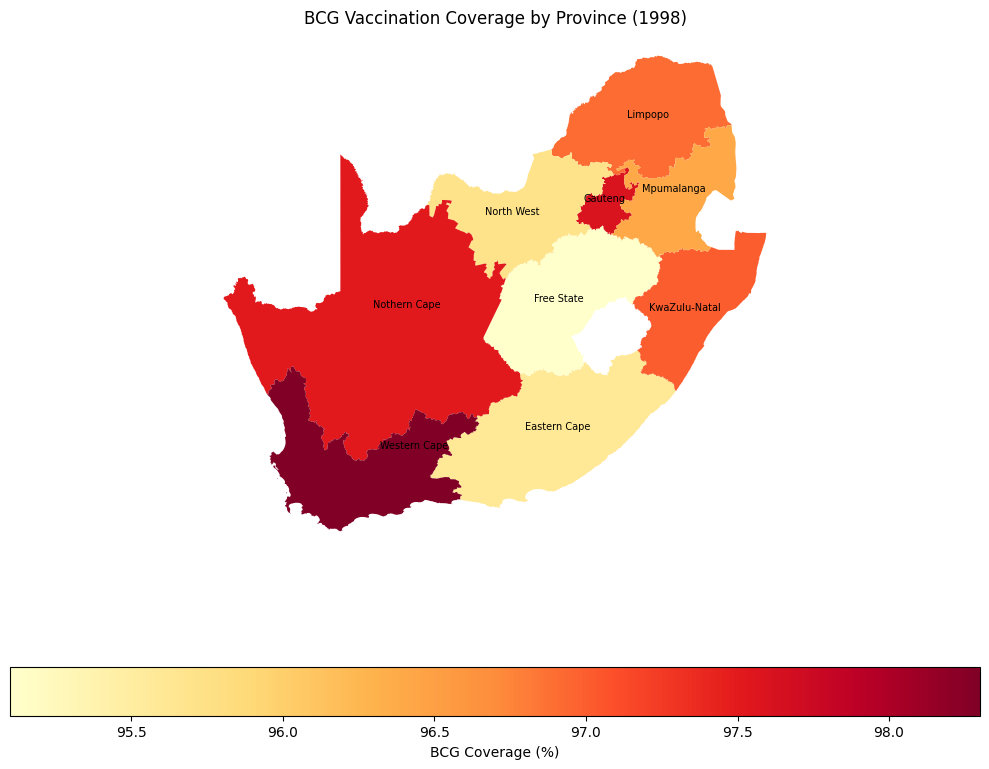

In [70]:
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(column='Value', ax=ax, legend=True, cmap='YlOrRd',
         legend_kwds={'label': 'BCG Coverage (%)', 'orientation': 'horizontal'})

# Label each province
for _, row in gdf.iterrows():
    ax.annotate(row['adm1_name'], xy=(row['center_lon'], row['center_lat']),
                ha='center', fontsize=7, color='black')

ax.set_title('BCG Vaccination Coverage by Province (1998)')
ax.set_axis_off()
plt.tight_layout()
plt.show()